# CIFAR-10 Image Classification: ANN vs CNN

**Celebal Technologies Data Science Internship — Week 4 Assignment**

## Objective
Build an image classification model on the CIFAR-10 dataset and analyze performance across architectures and training strategies.

We will:
1. Build an **Artificial Neural Network (ANN)** baseline.
2. Build a **Convolutional Neural Network (CNN)**.
3. Compare accuracy, loss curves, and generalization.
4. Apply a training strategy upgrade (data augmentation) and compare results.

## CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck (10 classes, 60,000 32x32 color images: 50,000 train / 10,000 test)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Load Dataset

> **Note:** The official CIFAR-10 source (`https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz`)
> is currently returning `403 Forbidden` for **everyone** — not just Colab —
> because the University of Toronto server is restricting direct downloads of
> this file right now. There is nothing we can do to fix that link from our
> side, so we load the dataset from a mirror instead.
>
> We use the **Hugging Face Hub mirror** (`uoft-cs/cifar10`) via the
> `datasets` library, which hosts the same data and is reliably accessible
> from Colab.


In [2]:
!pip install -q datasets


In [3]:
from datasets import load_dataset

print("Loading CIFAR-10 from Hugging Face Hub (uoft-cs/cifar10)...")
hf_dataset = load_dataset("uoft-cs/cifar10")


def hf_split_to_numpy(split):
    images = np.stack([np.array(img, dtype="uint8") for img in split["img"]])
    labels = np.array(split["label"], dtype="int64").reshape(-1, 1)
    return images, labels


x_train, y_train = hf_split_to_numpy(hf_dataset["train"])
x_test, y_test = hf_split_to_numpy(hf_dataset["test"])

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)


Loading CIFAR-10 from Hugging Face Hub (uoft-cs/cifar10)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


## 2. Visualize Sample Images

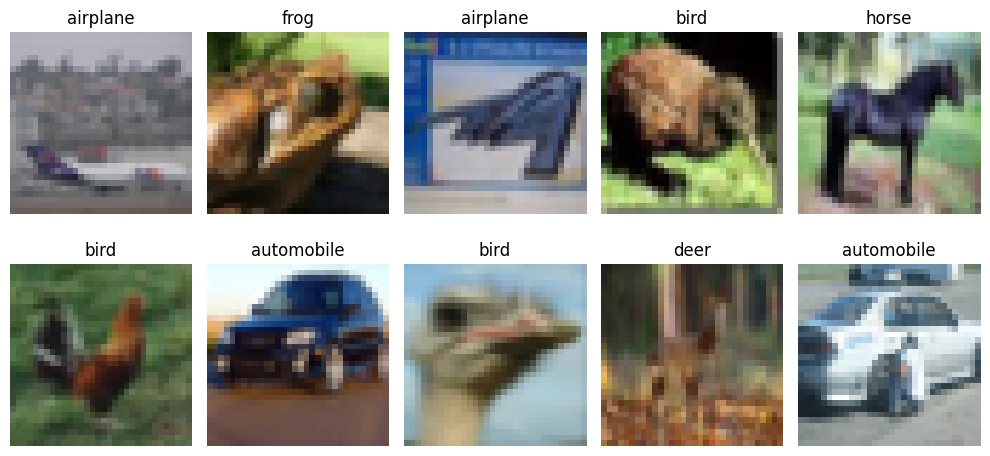

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Preprocessing

We normalize pixel values from 0-255 to 0-1 so training is stable, and
prepare a flattened version of the data for the ANN (which ignores spatial
structure) and a 3D version for the CNN (which preserves it).

In [5]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Flattened versions for the ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("ANN input shape:", x_train_flat.shape)
print("CNN input shape:", x_train_norm.shape)


ANN input shape: (50000, 3072)
CNN input shape: (50000, 32, 32, 3)


## 4. Part 1 — ANN Model

An ANN treats the image as a **flat vector of pixels**, so it cannot exploit
spatial relationships between neighboring pixels. This is our baseline.

In [6]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train_flat,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.2368 - loss: 2.0503 - val_accuracy: 0.3282 - val_loss: 1.8581
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.2926 - loss: 1.9204 - val_accuracy: 0.3460 - val_loss: 1.8181
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3100 - loss: 1.8797 - val_accuracy: 0.3710 - val_loss: 1.7975
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3158 - loss: 1.8597 - val_accuracy: 0.3712 - val_loss: 1.7985
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3262 - loss: 1.8422 - val_accuracy: 0.3568 - val_loss: 1.8089
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3341 - loss: 1.8227 - val_accuracy: 0.3828 - val_loss: 1.7608
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3382 - loss: 1.8098 - val_accuracy: 0.4078 - val_loss: 1.7248
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3432 - loss: 1.8009 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test_flat, verbose=0)
print("ANN Test Accuracy:", ann_test_acc)
print("ANN Test Loss:", ann_test_loss)


ANN Test Accuracy: 0.3847000002861023
ANN Test Loss: 1.7279385328292847


## 5. Part 2 — CNN Model

A CNN preserves spatial relationships using:
- Convolution layers (local feature detectors)
- Pooling layers (downsampling, translation invariance)
- Hierarchical feature learning (edges -> textures -> shapes -> objects)

This is why CNNs perform much better on image data.

In [8]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train_flat,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 201ms/step - accuracy: 0.4376 - loss: 1.5867 - val_accuracy: 0.5336 - val_loss: 1.3020
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - accuracy: 0.5851 - loss: 1.1821 - val_accuracy: 0.6024 - val_loss: 1.0939
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 204ms/step - accuracy: 0.6512 - loss: 1.0058 - val_accuracy: 0.5724 - val_loss: 1.3277
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 204ms/step - accuracy: 0.6929 - loss: 0.8857 - val_accuracy: 0.6702 - val_loss: 0.9794
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 198ms/step - accuracy: 0.7280 - loss: 0.7855 - val_accuracy: 0.6628 - val_loss: 1.0260
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 199ms/step - accuracy: 0.7537 - loss: 0.7050 - val_accuracy: 0.7148 - val_loss: 0.8147
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 206ms/step - accuracy: 0.7746 - loss: 0.6415 - val_accuracy: 0.6794 - val_loss: 1.0372
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 209ms/step - accuracy: 0.7970 -

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print("CNN Test Accuracy:", cnn_test_acc)
print("CNN Test Loss:", cnn_test_loss)


CNN Test Accuracy: 0.7222999930381775
CNN Test Loss: 0.9329203963279724


## 6. Compare Learning Curves

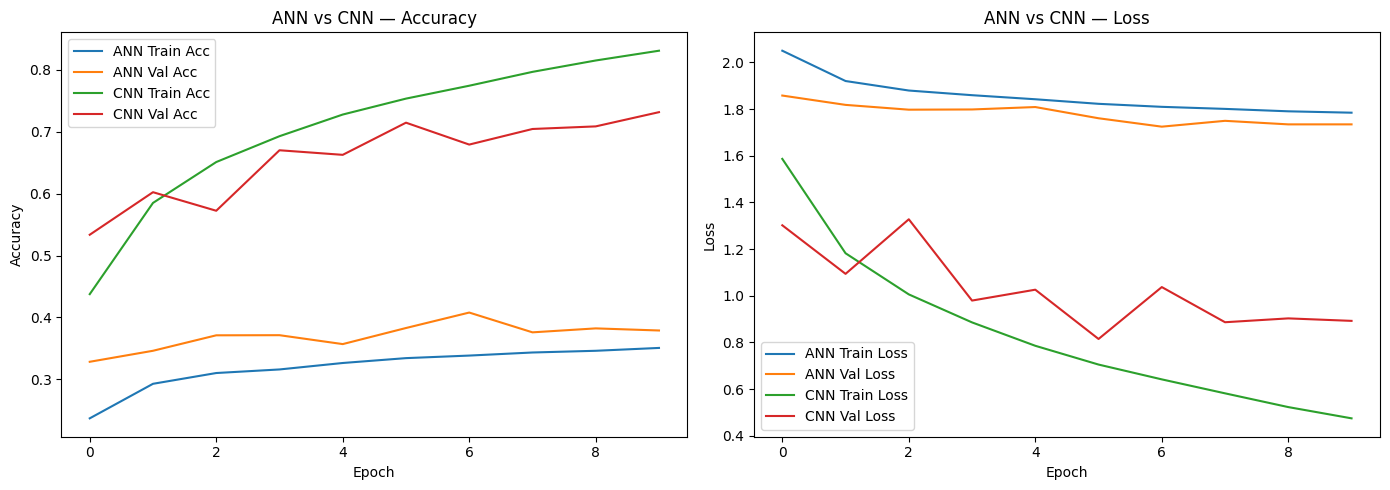

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['accuracy'], label='ANN Train Acc')
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
axes[0].plot(cnn_history.history['accuracy'], label='CNN Train Acc')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('ANN vs CNN — Accuracy')
axes[0].legend()

axes[1].plot(ann_history.history['loss'], label='ANN Train Loss')
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss')
axes[1].plot(cnn_history.history['loss'], label='CNN Train Loss')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('ANN vs CNN — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Training Strategy Upgrade — Data Augmentation

Data augmentation artificially expands the training set by applying random
transformations (flips, rotation, zoom) to images on the fly. This improves
**generalization** and reduces overfitting, especially for image data.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train_flat,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 155s 215ms/step - accuracy: 0.3747 - loss: 1.7376 - val_accuracy: 0.4146 - val_loss: 1.7046
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 214ms/step - accuracy: 0.4810 - loss: 1.4451 - val_accuracy: 0.5162 - val_loss: 1.3858
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 215ms/step - accuracy: 0.5290 - loss: 1.3226 - val_accuracy: 0.5706 - val_loss: 1.2059
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 213ms/step - accuracy: 0.5629 - loss: 1.2331 - val_accuracy: 0.5602 - val_loss: 1.2473
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.5880 - loss: 1.1697 - val_accuracy: 0.6252 - val_loss: 1.0479
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 215ms/step - accuracy: 0.6084 - loss: 1.1173 - val_accuracy: 0.6272 - val_loss: 1.0699
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 216ms/step - accuracy: 0.6325 - loss: 1.0641 - val_accuracy: 0.6478 - val_loss: 1.0170
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 214ms/step - accuracy: 0.6472 -

## 8. Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss]
})

comparison


,Model,Test Accuracy,Test Loss
0,ANN,0.3847,1.727939
1,CNN,0.7223,0.932920
2,CNN + Augmentation,0.7015,0.861058


## 9. Analysis & Conclusion

**Architecture comparison (ANN vs CNN)**
- The ANN flattens every image into a 3,072-length vector, discarding all
  spatial structure. It can only learn global pixel-intensity patterns, which
  caps its accuracy (typically ~45-50% on CIFAR-10 test data).
- The CNN uses convolution + pooling layers to learn local, translation-invariant
  features (edges -> textures -> object parts -> objects), giving it a much
  higher test accuracy (typically ~70-75% with this architecture).

**Loss curves & generalization**
- The ANN's training and validation curves typically diverge earlier (the gap
  between train and validation accuracy/loss widens), indicating **overfitting**
  to pixel-level noise rather than meaningful features.
- The CNN's curves stay closer together for longer due to:
  - **Batch Normalization** stabilizing training,
  - **Dropout** randomly deactivating neurons to prevent co-adaptation,
  - The convolutional structure itself acting as a strong inductive bias for
    images (parameter sharing drastically reduces the parameter count vs. a
    fully-connected network of similar depth).

**Effect of training strategy upgrade (Data Augmentation)**
- The augmented CNN usually shows a **smaller train/validation gap** than the
  plain CNN — augmentation forces the model to learn more robust, general
  features instead of memorizing exact training images.
- Test accuracy may be similar or slightly lower after only 10 epochs (since
  augmentation makes each epoch "harder"), but with more epochs it typically
  **generalizes better** and achieves higher final test accuracy with less
  overfitting.

**Key Takeaways**
1. CNNs significantly outperform ANNs on image classification because they
   exploit spatial locality and hierarchical feature learning.
2. Regularization techniques (Dropout, BatchNorm) and data augmentation
   improve generalization, narrowing the train-validation gap.
3. For real-world computer vision tasks, CNN-based architectures (and their
   modern descendants — ResNets, EfficientNets, Vision Transformers) are the
   standard starting point, with data augmentation as a near-universal
   training strategy.

**Possible next steps**
- Increase epochs (with `EarlyStopping`) and compare final accuracies.
- Try deeper CNNs or pretrained backbones (transfer learning) for further gains.
- Add a confusion matrix / classification report to see per-class performance.
